# Aula Prática 4 - Object Detection with YOLOv3

Nesta aula prática, exploraremos a detecção de objetos utilizando o modelo YOLOv3 (You Only Look Once). O YOLOv3 é uma das arquiteturas mais populares e eficientes para tarefas de detecção de objetos, conhecida por sua capacidade de realizar predições rápidas e precisas em tempo real.

O foco desta aula será na aplicação do YOLOv3 em um conjunto de dados contendo imagens de animais africanos, como:

- Rinoceronte
- Elefante
- Zebra
- Búfalo

Esse código foi inpirado no seguinte tutorial : [
YOLOv3 From Scratch Using PyTorch](https://www.geeksforgeeks.org/yolov3-from-scratch-using-pytorch/)

### Importando Bibliotecas

In [1]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision.io import read_image

import torch 
import torch.nn as nn 
import torch.optim as optim 
  
from PIL import Image, ImageFile 
ImageFile.LOAD_TRUNCATED_IMAGES = True
  
import albumentations as A 
from albumentations.pytorch import ToTensorV2 
import cv2 
  
import os 
import numpy as np 
import pandas as pd 
  
import matplotlib.pyplot as plt 
import matplotlib.patches as patches 
  
from tqdm import tqdm


## Funções Auxiliares

### Intersection over Union

In [2]:
 
# Defining a function to calculate Intersection over Union (IoU) 
def iou(box1, box2, is_pred=True): 
    if is_pred: 
        # IoU score for prediction and label 
        # box1 (prediction) and box2 (label) are both in [x, y, width, height] format 
          
        # Box coordinates of prediction 
        b1_x1 = box1[..., 0:1] - box1[..., 2:3] / 2
        b1_y1 = box1[..., 1:2] - box1[..., 3:4] / 2
        b1_x2 = box1[..., 0:1] + box1[..., 2:3] / 2
        b1_y2 = box1[..., 1:2] + box1[..., 3:4] / 2
  
        # Box coordinates of ground truth 
        b2_x1 = box2[..., 0:1] - box2[..., 2:3] / 2
        b2_y1 = box2[..., 1:2] - box2[..., 3:4] / 2
        b2_x2 = box2[..., 0:1] + box2[..., 2:3] / 2
        b2_y2 = box2[..., 1:2] + box2[..., 3:4] / 2
  
        # Get the coordinates of the intersection rectangle 
        x1 = torch.max(b1_x1, b2_x1) 
        y1 = torch.max(b1_y1, b2_y1) 
        x2 = torch.min(b1_x2, b2_x2) 
        y2 = torch.min(b1_y2, b2_y2) 
        # Make sure the intersection is at least 0 
        intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0) 
  
        # Calculate the union area 
        box1_area = abs((b1_x2 - b1_x1) * (b1_y2 - b1_y1)) 
        box2_area = abs((b2_x2 - b2_x1) * (b2_y2 - b2_y1)) 
        union = box1_area + box2_area - intersection 
  
        # Calculate the IoU score 
        epsilon = 1e-6
        iou_score = intersection / (union + epsilon) 
  
        # Return IoU score 
        return iou_score 
      
    else: 
        # IoU score based on width and height of bounding boxes 
          
        # Calculate intersection area 
        intersection_area = torch.min(box1[..., 0], box2[..., 0]) * torch.min(box1[..., 1], box2[..., 1]) 
  
        # Calculate union area 
        box1_area = box1[..., 0] * box1[..., 1] 
        box2_area = box2[..., 0] * box2[..., 1] 
        union_area = box1_area + box2_area - intersection_area 
  
        # Calculate IoU score 
        iou_score = intersection_area / union_area 
  
        # Return IoU score 
        return iou_score

### Non-Maximum Supression

In [3]:

# Non-maximum suppression function to remove overlapping bounding boxes 
def nms(bboxes, iou_threshold, threshold): 
    # Filter out bounding boxes with confidence below the threshold. 
    bboxes = [box for box in bboxes if box[1] > threshold] 
  
    # Sort the bounding boxes by confidence in descending order. 
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True) 
  
    # Initialize the list of bounding boxes after non-maximum suppression. 
    bboxes_nms = [] 
  
    while bboxes: 
        # Get the first bounding box. 
        first_box = bboxes.pop(0) 
  
        # Iterate over the remaining bounding boxes. 
        for box in bboxes: 
        # If the bounding boxes do not overlap or if the first bounding box has 
        # a higher confidence, then add the second bounding box to the list of 
        # bounding boxes after non-maximum suppression. 
            if box[0] != first_box[0] or iou( 
                torch.tensor(first_box[2:]), 
                torch.tensor(box[2:]), 
            ) < iou_threshold: 
                # Check if box is not in bboxes_nms 
                if box not in bboxes_nms: 
                    # Add box to bboxes_nms 
                    bboxes_nms.append(box) 
  
    # Return bounding boxes after non-maximum suppression. 
    return bboxes_nms

### Converte célular para bounding boxes

In [4]:
# Function to convert cells to bounding boxes 
def convert_cells_to_bboxes(predictions, anchors, s, is_predictions=True): 
    # Batch size used on predictions 
    batch_size = predictions.shape[0] 
    # Number of anchors 
    num_anchors = len(anchors) 
    # List of all the predictions 
    box_predictions = predictions[..., 1:5] 
  
    # If the input is predictions then we will pass the x and y coordinate 
    # through sigmoid function and width and height to exponent function and 
    # calculate the score and best class. 
    if is_predictions: 
        anchors = anchors.reshape(1, len(anchors), 1, 1, 2) 
        box_predictions[..., 0:2] = torch.sigmoid(box_predictions[..., 0:2]) 
        box_predictions[..., 2:] = torch.exp( 
            box_predictions[..., 2:]) * anchors 
        scores = torch.sigmoid(predictions[..., 0:1]) 
        best_class = torch.argmax(predictions[..., 5:], dim=-1).unsqueeze(-1) 
      
    # Else we will just calculate scores and best class. 
    else: 
        scores = predictions[..., 0:1] 
        best_class = predictions[..., 5:6] 
  
    # Calculate cell indices 
    cell_indices = ( 
        torch.arange(s) 
        .repeat(predictions.shape[0], 3, s, 1) 
        .unsqueeze(-1) 
        .to(predictions.device) 
    ) 
  
    # Calculate x, y, width and height with proper scaling 
    x = 1 / s * (box_predictions[..., 0:1] + cell_indices) 
    y = 1 / s * (box_predictions[..., 1:2] +
                 cell_indices.permute(0, 1, 3, 2, 4)) 
    width_height = 1 / s * box_predictions[..., 2:4] 
  
    # Concatinating the values and reshaping them in 
    # (BATCH_SIZE, num_anchors * S * S, 6) shape 
    converted_bboxes = torch.cat( 
        (best_class, scores, x, y, width_height), dim=-1
    ).reshape(batch_size, num_anchors * s * s, 6) 
  
    # Returning the reshaped and converted bounding box list 
    return converted_bboxes.tolist()

### Plota imagem com bounding boxes

In [5]:
 
# Function to plot images with bounding boxes and class labels 
def plot_image(image, boxes): 
    # Getting the color map from matplotlib 
    colour_map = plt.get_cmap("tab20b") 
    # Getting 20 different colors from the color map for 20 different classes 
    colors = [colour_map(i) for i in np.linspace(0, 1, len(class_labels))] 
  
    # Reading the image with OpenCV 
    img = np.array(image) 
    # Getting the height and width of the image 
    h, w, _ = img.shape 
  
    # Create figure and axes 
    fig, ax = plt.subplots(1) 
  
    # Add image to plot 
    ax.imshow(img) 
  
    # Plotting the bounding boxes and labels over the image 
    for box in boxes: 
        # Get the class from the box 
        class_pred = box[0] 
        # Get the center x and y coordinates 
        box = box[2:] 
        # Get the upper left corner coordinates 
        upper_left_x = box[0] - box[2] / 2
        upper_left_y = box[1] - box[3] / 2
  
        # Create a Rectangle patch with the bounding box 
        rect = patches.Rectangle( 
            (upper_left_x * w, upper_left_y * h), 
            box[2] * w, 
            box[3] * h, 
            linewidth=2, 
            edgecolor=colors[int(class_pred)], 
            facecolor="none", 
        ) 
          
        # Add the patch to the Axes 
        ax.add_patch(rect) 
          
        # Add class name to the patch 
        plt.text( 
            upper_left_x * w, 
            upper_left_y * h, 
            s=class_labels[int(class_pred)], 
            color="white", 
            verticalalignment="top", 
            bbox={"color": colors[int(class_pred)], "pad": 0}, 
        ) 
  
    # Display the plot 
    plt.show()

### Save and Load Checkpoint

In [6]:
 
# Function to save checkpoint 
def save_checkpoint(model, optimizer, filename="my_checkpoint.pth.tar"): 
    print("==> Saving checkpoint") 
    checkpoint = { 
        "state_dict": model.state_dict(), 
        "optimizer": optimizer.state_dict(), 
    } 
    torch.save(checkpoint, filename)

In [7]:
 
# Function to load checkpoint 
def load_checkpoint(checkpoint_file, model, optimizer, lr): 
    print("==> Loading checkpoint") 
    checkpoint = torch.load(checkpoint_file, map_location=device) 
    model.load_state_dict(checkpoint["state_dict"]) 
    optimizer.load_state_dict(checkpoint["optimizer"]) 
  
    for param_group in optimizer.param_groups: 
        param_group["lr"] = lr 

## Definindo Hiperparâmetros

In [8]:
 
# Device 
device = "cuda" if torch.cuda.is_available() else "cpu"
  
# Load and save model variable 
load_model = False
save_model = True
  
# model checkpoint file name 
checkpoint_file = "checkpoint.pth.tar"
  
# Anchor boxes for each feature map scaled between 0 and 1 
# 3 feature maps at 3 different scales based on YOLOv3 paper 
ANCHORS = [ 
    [(0.28, 0.22), (0.38, 0.48), (0.9, 0.78)], 
    [(0.07, 0.15), (0.15, 0.11), (0.14, 0.29)], 
    [(0.02, 0.03), (0.04, 0.07), (0.08, 0.06)], 
] 
  

# # Defina as âncoras usadas pelo YOLOv3
# ANCHORS = [
#     [(10,13), (16,30), (33,23)],
#     [(30,61), (62,45), (59,119)],
#     [(116,90), (156,198), (373,326)]
# ]    

# Batch size for training 
batch_size = 8
  
# Learning rate for training 
leanring_rate = 1e-5
  
# Number of epochs for training 
epochs = 20
  
# Image size 
image_size = 416
  
# Grid cell sizes 
s = [image_size // 32, image_size // 16, image_size // 8] 
  
# Class labels 
class_labels = [ 
    "buffalo", "elephant","rhino","zebra"
]




## Cruiando uma classe de Dataset Customizado

In [9]:
class YOLODataset(Dataset):
    def __init__(self, base_folder_path, anchors, image_size=416, grid_sizes=[13, 26, 52], 
                 num_classes=4, transform=None):
        # Inicializa a classe com as variáveis base, como o caminho da pasta, âncoras, tamanho da imagem, etc.
        self.base_folder_path = base_folder_path
        self.image_size = image_size
        self.transform = transform
        self.grid_sizes = grid_sizes
        # Concatena as âncoras de diferentes escalas e converte para tensor
        self.anchors = torch.tensor(anchors[0] + anchors[1] + anchors[2])
        self.num_anchors = self.anchors.shape[0]  # Total de âncoras
        self.num_anchors_per_scale = self.num_anchors // 3  # Número de âncoras por escala (3 escalas no YOLO)
        self.num_classes = num_classes
        self.ignore_iou_thresh = 0.5  # Limiar de IOU para ignorar certas âncoras

        # Lista de arquivos de imagem (.jpg) e texto (.txt)
        self.image_files = []
        # Procura por arquivos de imagem em cada subpasta correspondente às classes (búfalo, elefante, etc.)
        for folder in ['buffalo', 'elephant', 'rhino', 'zebra']:
            folder_path = os.path.join(base_folder_path, folder)
            for file in os.listdir(folder_path):
                if file.endswith(".jpg"):  # Verifica se é um arquivo .jpg
                    self.image_files.append(os.path.join(folder_path, file))
        
        # Exibe quantas imagens foram encontradas
        print(f"Found {len(self.image_files)} images.")

    def __len__(self):
        # Retorna o número total de imagens no dataset
        return len(self.image_files)

    def __getitem__(self, idx):
        # Obtém o caminho da imagem e do arquivo de rótulos correspondente para o índice dado
        img_path = self.image_files[idx]
        label_path = img_path.replace(".jpg", ".txt")
        
        # Carrega a imagem e normaliza os valores dos pixels para o intervalo [0, 1]
        image = read_image(img_path).float() / 255.0

        bboxes = []  # Lista de caixas delimitadoras (bounding boxes)
        # Verifica se o arquivo de rótulo existe e carrega as caixas delimitadoras
        if os.path.exists(label_path):
            with open(label_path, 'r') as file:
                for line in file:
                    # Cada linha no arquivo contém a classe e as coordenadas da caixa
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_label, x, y, width, height = map(float, parts)
                        # Adiciona a caixa delimitadora na lista
                        bboxes.append([x, y, width, height, class_label])

        # Aplica as transformações (data augmentation) se fornecidas
        if self.transform:
            augs = self.transform(image=image.numpy(), bboxes=bboxes)
            image = torch.tensor(augs["image"]).float()
            bboxes = augs["bboxes"]

        # Redimensiona a imagem para o tamanho desejado (image_size) se necessário
        if image.shape[0] != self.image_size:
            image = torch.nn.functional.interpolate(
                image.unsqueeze(0), 
                size=(self.image_size, self.image_size), 
                mode='bilinear', align_corners=False
            ).squeeze(0)

        # Inicializa os tensores de destino (targets) para cada escala de saída (13x13, 26x26, 52x52)
        targets = [torch.zeros((self.num_anchors_per_scale, s, s, 6)) for s in self.grid_sizes]

        # Para cada caixa delimitadora, calcula a correspondência com as âncoras
        for box in bboxes:
            # Calcula o IOU (Intersection over Union) entre a caixa e todas as âncoras
            iou_anchors = iou(torch.tensor(box[2:4]), self.anchors, is_pred=False)
            # Ordena os índices das âncoras com base no IOU, do maior para o menor
            anchor_indices = iou_anchors.argsort(descending=True, dim=0)
            x, y, width, height, class_label = box

            # Variável para garantir que apenas uma âncora seja atribuída por escala
            has_anchor = [False] * 3
            for anchor_idx in anchor_indices:
                # Calcula em qual escala e âncora está o índice
                scale_idx = anchor_idx // self.num_anchors_per_scale
                anchor_on_scale = anchor_idx % self.num_anchors_per_scale
                s = self.grid_sizes[scale_idx]
                # Calcula a posição (i, j) na grade com base nas coordenadas (x, y)
                i, j = int(s * y), int(s * x)

                anchor_taken = targets[scale_idx][anchor_on_scale, i, j, 0]

                # Se a âncora não foi usada e nenhuma outra âncora foi atribuída nesta escala
                if not anchor_taken and not has_anchor[scale_idx]:
                    # Marca que há um objeto nessa célula
                    targets[scale_idx][anchor_on_scale, i, j, 0] = 1
                    # Converte as coordenadas da caixa para o espaço da célula
                    x_cell, y_cell = s * x - j, s * y - i
                    width_cell, height_cell = (width * s, height * s)

                    # Armazena as coordenadas da caixa no tensor de destino
                    box_coordinates = torch.tensor([x_cell, y_cell, width_cell, height_cell])
                    targets[scale_idx][anchor_on_scale, i, j, 1:5] = box_coordinates
                    # Armazena o rótulo da classe
                    targets[scale_idx][anchor_on_scale, i, j, 5] = int(class_label)
                    # Marca que uma âncora foi atribuída para esta escala
                    has_anchor[scale_idx] = True

                # Caso a âncora não tenha sido usada e tenha IOU maior que o limiar, marca para ignorar
                elif not anchor_taken and iou_anchors[anchor_idx] > self.ignore_iou_thresh:
                    targets[scale_idx][anchor_on_scale, i, j, 0] = -1

        # Retorna a imagem e os alvos (targets) como tuplas, um para cada escala
        return image, tuple(targets)


## Dataset e Dataloader

In [10]:
# Defina o caminho para o diretório onde estão as imagens e anotações
folder_path = "/kaggle/input/african-wildlife"


# Cria o dataset
dataset = YOLODataset(folder_path, ANCHORS , num_classes=4)

# Cria o DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Found 1501 images.


## Mostrando um exemplo 

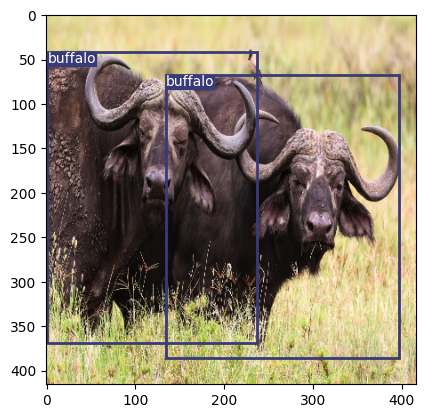

In [11]:

# Defining the grid size and the scaled anchors 
GRID_SIZE = [13, 26, 52] 
scaled_anchors = torch.tensor(ANCHORS) / ( 
    1 / torch.tensor(GRID_SIZE).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2) 
) 
  
# Getting a batch from the dataloader 
x, y = next(iter(dataloader)) 
  
# Getting the boxes coordinates from the labels 
# and converting them into bounding boxes without scaling 
boxes = [] 
for i in range(y[0].shape[1]): 
    anchor = scaled_anchors[i] 
    boxes += convert_cells_to_bboxes( 
               y[i], is_predictions=False, s=y[i].shape[2], anchors=anchor 
             )[0] 
  
# Applying non-maximum suppression 
boxes = nms(boxes, iou_threshold=1, threshold=0.7) 
  
# Plotting the image with the bounding boxes 
plot_image(x[0].permute(1,2,0).to("cpu"), boxes)

## Construindo o Modelo

![arquitetura](https://media.dev.to/cdn-cgi/image/width=800%2Cheight=%2Cfit=scale-down%2Cgravity=auto%2Cformat=auto/https%3A%2F%2Fdev-to-uploads.s3.amazonaws.com%2Fuploads%2Farticles%2Fnr5oq1n6ukg89z8e6ytl.png)

In [12]:

# Defining CNN Block 
class CNNBlock(nn.Module): 
    def __init__(self, in_channels, out_channels, use_batch_norm=True, **kwargs): 
        super().__init__() 
        self.conv = nn.Conv2d(in_channels, out_channels, bias=not use_batch_norm, **kwargs) 
        self.bn = nn.BatchNorm2d(out_channels) 
        self.activation = nn.LeakyReLU(0.1) 
        self.use_batch_norm = use_batch_norm 
  
    def forward(self, x): 
        # Applying convolution 
        x = self.conv(x) 
        # Applying BatchNorm and activation if needed 
        if self.use_batch_norm: 
            x = self.bn(x) 
            return self.activation(x) 
        else: 
            return x

In [13]:
  
# Defining residual block 
class ResidualBlock(nn.Module): 
    def __init__(self, channels, use_residual=True, num_repeats=1): 
        super().__init__() 
          
        # Defining all the layers in a list and adding them based on number of  
        # repeats mentioned in the design 
        res_layers = [] 
        for _ in range(num_repeats): 
            res_layers += [ 
                nn.Sequential( 
                    nn.Conv2d(channels, channels // 2, kernel_size=1), 
                    nn.BatchNorm2d(channels // 2), 
                    nn.LeakyReLU(0.1), 
                    nn.Conv2d(channels // 2, channels, kernel_size=3, padding=1), 
                    nn.BatchNorm2d(channels), 
                    nn.LeakyReLU(0.1) 
                ) 
            ] 
        self.layers = nn.ModuleList(res_layers) 
        self.use_residual = use_residual 
        self.num_repeats = num_repeats 
      
    # Defining forward pass 
    def forward(self, x): 
        for layer in self.layers: 
            residual = x 
            x = layer(x) 
            if self.use_residual: 
                x = x + residual 
        return x

In [14]:
   
# Defining scale prediction class 
class ScalePrediction(nn.Module): 
    def __init__(self, in_channels, num_classes): 
        super().__init__() 
        # Defining the layers in the network 
        self.pred = nn.Sequential( 
            nn.Conv2d(in_channels, 2*in_channels, kernel_size=3, padding=1), 
            nn.BatchNorm2d(2*in_channels), 
            nn.LeakyReLU(0.1), 
            nn.Conv2d(2*in_channels, (num_classes + 5) * 3, kernel_size=1), 
        ) 
        self.num_classes = num_classes 
      
    # Defining the forward pass and reshaping the output to the desired output  
    # format: (batch_size, 3, grid_size, grid_size, num_classes + 5) 
    def forward(self, x): 
        output = self.pred(x) 
        output = output.view(x.size(0), 3, self.num_classes + 5, x.size(2), x.size(3)) 
        output = output.permute(0, 1, 3, 4, 2) 
        return output

In [15]:
   
# Class for defining YOLOv3 model 
class YOLOv3(nn.Module): 
    def __init__(self, in_channels=3, num_classes=20): 
        super().__init__() 
        self.num_classes = num_classes 
        self.in_channels = in_channels 
  
        # Layers list for YOLOv3 
        self.layers = nn.ModuleList([ 
            CNNBlock(in_channels, 32, kernel_size=3, stride=1, padding=1), 
            CNNBlock(32, 64, kernel_size=3, stride=2, padding=1), 
            ResidualBlock(64, num_repeats=1), 
            CNNBlock(64, 128, kernel_size=3, stride=2, padding=1), 
            ResidualBlock(128, num_repeats=2), 
            CNNBlock(128, 256, kernel_size=3, stride=2, padding=1), 
            ResidualBlock(256, num_repeats=8), 
            CNNBlock(256, 512, kernel_size=3, stride=2, padding=1), 
            ResidualBlock(512, num_repeats=8), 
            CNNBlock(512, 1024, kernel_size=3, stride=2, padding=1), 
            ResidualBlock(1024, num_repeats=4), 
            CNNBlock(1024, 512, kernel_size=1, stride=1, padding=0), 
            CNNBlock(512, 1024, kernel_size=3, stride=1, padding=1), 
            ResidualBlock(1024, use_residual=False, num_repeats=1), 
            CNNBlock(1024, 512, kernel_size=1, stride=1, padding=0), 
            ScalePrediction(512, num_classes=num_classes), 
            CNNBlock(512, 256, kernel_size=1, stride=1, padding=0), 
            nn.Upsample(scale_factor=2), 
            CNNBlock(768, 256, kernel_size=1, stride=1, padding=0), 
            CNNBlock(256, 512, kernel_size=3, stride=1, padding=1), 
            ResidualBlock(512, use_residual=False, num_repeats=1), 
            CNNBlock(512, 256, kernel_size=1, stride=1, padding=0), 
            ScalePrediction(256, num_classes=num_classes), 
            CNNBlock(256, 128, kernel_size=1, stride=1, padding=0), 
            nn.Upsample(scale_factor=2), 
            CNNBlock(384, 128, kernel_size=1, stride=1, padding=0), 
            CNNBlock(128, 256, kernel_size=3, stride=1, padding=1), 
            ResidualBlock(256, use_residual=False, num_repeats=1), 
            CNNBlock(256, 128, kernel_size=1, stride=1, padding=0), 
            ScalePrediction(128, num_classes=num_classes) 
        ]) 
      
    # Forward pass for YOLOv3 with route connections and scale predictions 
    def forward(self, x): 
        outputs = [] 
        route_connections = [] 
  
        for layer in self.layers: 
            if isinstance(layer, ScalePrediction): 
                outputs.append(layer(x)) 
                continue
            x = layer(x) 
  
            if isinstance(layer, ResidualBlock) and layer.num_repeats == 8: 
                route_connections.append(x) 
              
            elif isinstance(layer, nn.Upsample): 
                x = torch.cat([x, route_connections[-1]], dim=1) 
                route_connections.pop() 
        return outputs

### Testando a Saída do Modelo

In [16]:
  
# Testing YOLO v3 model 
if __name__ == "__main__": 
    # Setting number of classes and image size 
    num_classes = 4
    IMAGE_SIZE = 416
  
    # Creating model and testing output shapes 
    model = YOLOv3(num_classes=num_classes) 
    x = torch.randn((1, 3, IMAGE_SIZE, IMAGE_SIZE)) 
    out = model(x) 
    print(out[0].shape) 
    print(out[1].shape) 
    print(out[2].shape) 
  
    # Asserting output shapes 
    assert model(x)[0].shape == (1, 3, IMAGE_SIZE//32, IMAGE_SIZE//32, num_classes + 5) 
    assert model(x)[1].shape == (1, 3, IMAGE_SIZE//16, IMAGE_SIZE//16, num_classes + 5) 
    assert model(x)[2].shape == (1, 3, IMAGE_SIZE//8, IMAGE_SIZE//8, num_classes + 5) 
    print("Output shapes are correct!")

torch.Size([1, 3, 13, 13, 9])
torch.Size([1, 3, 26, 26, 9])
torch.Size([1, 3, 52, 52, 9])
Output shapes are correct!


## Criando uma Loss específica

In [17]:
 
# Defining YOLO loss class 
class YOLOLoss(nn.Module): 
    def __init__(self): 
        super().__init__() 
        self.mse = nn.MSELoss() 
        self.bce = nn.BCEWithLogitsLoss() 
        self.cross_entropy = nn.CrossEntropyLoss() 
        self.sigmoid = nn.Sigmoid() 
      
    def forward(self, pred, target, anchors): 
        # Identifying which cells in target have objects  
        # and which have no objects 
        obj = target[..., 0] == 1
        no_obj = target[..., 0] == 0
  
        # Calculating No object loss 
        no_object_loss = self.bce( 
            (pred[..., 0:1][no_obj]), (target[..., 0:1][no_obj]), 
        ) 
  
          
        # Reshaping anchors to match predictions 
        anchors = anchors.reshape(1, 3, 1, 1, 2) 
        # Box prediction confidence 
        box_preds = torch.cat([self.sigmoid(pred[..., 1:3]), 
                               torch.exp(pred[..., 3:5]) * anchors 
                            ],dim=-1) 
        # Calculating intersection over union for prediction and target 
        ious = iou(box_preds[obj], target[..., 1:5][obj]).detach() 
        # Calculating Object loss 
        object_loss = self.mse(self.sigmoid(pred[..., 0:1][obj]), 
                               ious * target[..., 0:1][obj]) 
  
          
        # Predicted box coordinates 
        pred[..., 1:3] = self.sigmoid(pred[..., 1:3]) 
        # Target box coordinates 
        target[..., 3:5] = torch.log(1e-6 + target[..., 3:5] / anchors) 
        # Calculating box coordinate loss 
        box_loss = self.mse(pred[..., 1:5][obj], 
                            target[..., 1:5][obj]) 
  
          
        # Claculating class loss 
        class_loss = self.cross_entropy((pred[..., 5:][obj]), 
                                   target[..., 5][obj].long()) 
  
        # Total loss 
        return ( 
            box_loss 
            + object_loss 
            + no_object_loss 
            + class_loss 
        )

### Loop de Treinamento

In [18]:
 
# Define the train function to train the model 
def training_loop(loader, model, optimizer, loss_fn, scaler, scaled_anchors): 
    # Creating a progress bar 
    progress_bar = tqdm(loader, leave=True) 
  
    # Initializing a list to store the losses 
    losses = [] 
  
    # Iterating over the training data 
    for _, (x, y) in enumerate(progress_bar): 
        x = x.to(device) 
        y0, y1, y2 = ( 
            y[0].to(device), 
            y[1].to(device), 
            y[2].to(device), 
        ) 
  
        with torch.cuda.amp.autocast(): 
            # Getting the model predictions 
            outputs = model(x) 
            # Calculating the loss at each scale 
            loss = ( 
                  loss_fn(outputs[0], y0, scaled_anchors[0]) 
                + loss_fn(outputs[1], y1, scaled_anchors[1]) 
                + loss_fn(outputs[2], y2, scaled_anchors[2]) 
            ) 
  
        # Add the loss to the list 
        losses.append(loss.item()) 
  
        # Reset gradients 
        optimizer.zero_grad() 
  
        # Backpropagate the loss 
        scaler.scale(loss).backward() 
  
        # Optimization step 
        scaler.step(optimizer) 
  
        # Update the scaler for next iteration 
        scaler.update() 
  
        # update progress bar with loss 
        mean_loss = sum(losses) / len(losses) 
        progress_bar.set_postfix(loss=mean_loss)

## Treinando o Modelo

In [19]:

# # Creating the model from YOLOv3 class 
# model = YOLOv3().to(device) 
  
# # Defining the optimizer 
# optimizer = optim.Adam(model.parameters(), lr = 0.001) 
  
# # Defining the loss function 
# loss_fn = YOLOLoss() 
  
# # Defining the scaler for mixed precision training 
# scaler = torch.cuda.amp.GradScaler() 
  

# # Scaling the anchors 
# scaled_anchors = ( 
#     torch.tensor(ANCHORS) * 
#     torch.tensor(s).unsqueeze(1).unsqueeze(1).repeat(1,3,2) 
# ).to(device) 
  
# # Training the model 
# for e in range(1, epochs+1): 
#     print("Epoch:", e) 
#     training_loop(dataloader, model, optimizer, loss_fn, scaler, scaled_anchors) 
  
#     # Saving the model 
#     if save_model: 
#         save_checkpoint(model, optimizer, filename=f"checkpoint.pth.tar")
  


## Observando Resultados

### Baixando pesos - 60 epochs

In [20]:
!pip install gdown

In [21]:
!gdown 1mNgYyxizy9vrZd_R-uAA3k-Jw-foVt8Q

Downloading...
From (original): https://drive.google.com/uc?id=1mNgYyxizy9vrZd_R-uAA3k-Jw-foVt8Q
From (redirected): https://drive.google.com/uc?id=1mNgYyxizy9vrZd_R-uAA3k-Jw-foVt8Q&confirm=t&uuid=cfd62a4a-c372-4056-959c-b52ca27a3bf4
To: /kaggle/working/checkpoint.pth.tar
100%|████████████████████████████████████████| 740M/740M [00:18<00:00, 39.9MB/s]


In [22]:
# Setting the load_model to True 
load_model = True

checkpoint_file = "/kaggle/working/checkpoint.pth.tar"
  
# Defining the model, optimizer, loss function and scaler 
model = YOLOv3().to(device) 
optimizer = optim.Adam(model.parameters(), lr = leanring_rate) 
loss_fn = YOLOLoss() 
scaler = torch.cuda.amp.GradScaler() 
  
# Loading the checkpoint 
if load_model: 
    load_checkpoint(checkpoint_file, model, optimizer, leanring_rate) 

/tmp/ipykernel_36/2967624692.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_36/3894978885.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full cont

==> Loading checkpoint


In [ ]:
# Scaling the anchors 
scaled_anchors = ( 
    torch.tensor(ANCHORS) * 
    torch.tensor(s).unsqueeze(1).unsqueeze(1).repeat(1,3,2) 
).to(device) 
  
    
model.train()

# Training the model 
for e in range(epochs + 41, epochs+81): 
    print("Epoch:", e) 
    training_loop(dataloader, model, optimizer, loss_fn, scaler, scaled_anchors) 
  
    # Saving the model 
    if save_model: 
        save_checkpoint(model, optimizer, filename=f"checkpoint.pth.tar")

Epoch: 61


  0%|          | 0/188 [00:00<?, ?it/s]/tmp/ipykernel_36/3708770706.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 188/188 [01:33<00:00,  2.01it/s, loss=0.514]


==> Saving checkpoint
Epoch: 62


100%|██████████| 188/188 [01:14<00:00,  2.53it/s, loss=0.503]


==> Saving checkpoint
Epoch: 63


...

100%|██████████| 188/188 [01:13<00:00,  2.55it/s, loss=0.481]


==> Saving checkpoint
Epoch: 68


100%|██████████| 188/188 [01:14<00:00,  2.54it/s, loss=0.49] 


==> Saving checkpoint
Epoch: 69


 73%|███████▎  | 137/188 [00:53<00:19,  2.55it/s, loss=0.48] 

In [ ]:

  
# Getting a sample image from the test data loader 
x, y = next(iter(dataloader)) 
x = x.to(device) 
  
model.eval() 
with torch.no_grad(): 
    # Getting the model predictions 
    output = model(x) 
    # Getting the bounding boxes from the predictions 
    bboxes = [[] for _ in range(x.shape[0])] 
    anchors = ( 
            torch.tensor(ANCHORS ) 
                * torch.tensor(s).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2) 
            ).to(device) 
  
    # Getting bounding boxes for each scale 
    for i in range(3): 
        batch_size, A, S, _, _ = output[i].shape 
        anchor = anchors[i] 
        boxes_scale_i = convert_cells_to_bboxes( 
                            output[i], anchor, s=S, is_predictions=True
                        ) 
        for idx, (box) in enumerate(boxes_scale_i): 
            bboxes[idx] += box 
model.train() 
  
# Plotting the image with bounding boxes for each image in the batch 
for i in range(batch_size): 
    # Applying non-max suppression to remove overlapping bounding boxes 
    nms_boxes = nms(bboxes[i], iou_threshold=0.80, threshold=0.75) 
    # Plotting the image with bounding boxes 
    plot_image(x[i].permute(1,2,0).detach().cpu(), nms_boxes)